# 🌫️ Air Quality & Pollution Assessment: ML for Environmental Monitoring

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying air quality levels from pollution metrics to support public health and environmental regulation  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for classifying air quality categories based on pollutant concentrations and environmental metrics. The model supports **real-time air quality monitoring** and public health advisories.

### Government Policy Context
- **DCCEEW** — National Clean Air Agreement, National Environment Protection (Ambient Air Quality) Measure (NEPM AAQ)
- **State/Territory EPAs** — Air quality monitoring networks, pollution event response, bushfire smoke advisories
- **Department of Health** — Air quality health index, vulnerable population advisories (asthma, COPD)
- **Bureau of Meteorology** — Air quality forecasting, smoke dispersion modelling
- **CSIRO** — Atmospheric research, emissions inventory, climate-air quality interactions

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Hazardous | Public health emergency advisory, school closures | Health dept + EPA |
| Poor | Sensitive groups advisory, outdoor activity restrictions | Local council + Health |
| Moderate | Monitoring intensified, standard advisory | EPA automated system |
| Good | Routine operations | No action required |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/mujtabamatin/air-quality-and-pollution-assessment/updated_pollution_dataset.csv

Loaded: 5,000 rows x 10 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Temperature                         | float64    | unique=   362 | nulls=  0 | eg: 29.8
   1. Humidity                            | float64    | unique=   723 | nulls=  0 | eg: 59.1
   2. PM2.5                               | float64    | unique=   815 | nulls=  0 | eg: 5.2
   3. PM10                                | float64    | unique=   955 | nulls=  0 | eg: 17.9
   4. NO2                                 | float64    | unique=   445 | nulls=  0 | eg: 18.9
   5. SO2                                 | float64    | unique=   348 | nulls=  0 | eg: 9.2
   6. CO                                  | float64    | unique=   265 | nulls=  0 | eg: 1.72
   7. Proximity_to_Industrial_Areas       | float64    | unique=   179 | nulls=  0 | eg: 6.3
   8. Population_Density                  | int64      | unique=   683 | nulls=  0 | eg: 319
   9. Air Quality                         | object     | unique=     4 | nulls=  0 | eg: Moderate


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['Air Quality', 'AQI_Category', 'air_quality', 'Air_Quality',
                     'AQI_Bucket', 'AQI', 'Target', 'target', 'Class', 'class',
                     'Air Quality Level', 'Quality']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    # Check for columns with low cardinality categorical values that look like quality labels
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() <= 10:
            vals = df[col].unique()
            quality_keywords = ['good', 'moderate', 'poor', 'hazardous', 'unhealthy', 'dangerous']
            if any(kw in str(v).lower() for v in vals for kw in quality_keywords):
                target_col = col
                print(f"Auto-detected target: '{target_col}' (contains quality labels)")
                break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback — last column: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

# Encode target
if df[target_col].dtype == 'object':
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])
    print(f"\nEncoded classes: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
    target_labels = list(le_target.classes_)
else:
    target_labels = [str(x) for x in sorted(df[target_col].unique())]

print(f"\nDistribution after encoding:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2


Found target: 'Air Quality'

Raw values:
Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64

Encoded classes: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Poor': np.int64(3)}

Distribution after encoding:
Air Quality
0    2000
1     500
2    1500
3    1000
Name: count, dtype: int64


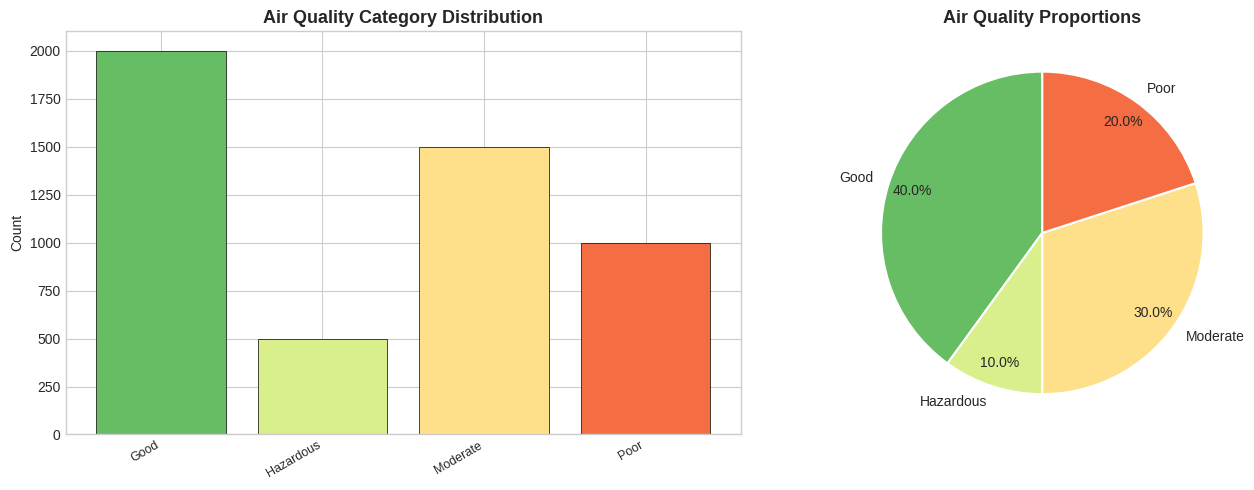

Australian context: Major air quality events include bushfire smoke (2019-20 Black Summer),
mining dust, urban vehicle emissions, and industrial pollution in Hunter Valley/Latrobe Valley.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
n_classes = len(vc)
colors = sns.color_palette('RdYlGn_r', n_colors=n_classes)
labels = target_labels if len(target_labels) == n_classes else [f'Class {x}' for x in vc.index]

axes[0].bar(range(n_classes), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(n_classes))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Air Quality Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Air Quality Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Australian context: Major air quality events include bushfire smoke (2019-20 Black Summer),")
print("mining dust, urban vehicle emissions, and industrial pollution in Hunter Valley/Latrobe Valley.")


## 3. Exploratory Data Analysis

Key questions for environmental policy:
- Which pollutants most strongly determine air quality category?
- Are there threshold effects (WHO/NEPM guideline exceedances)?
- Do temperature/humidity interact with pollution levels?
- Are there geographic or seasonal patterns?


Numeric features (9): ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']


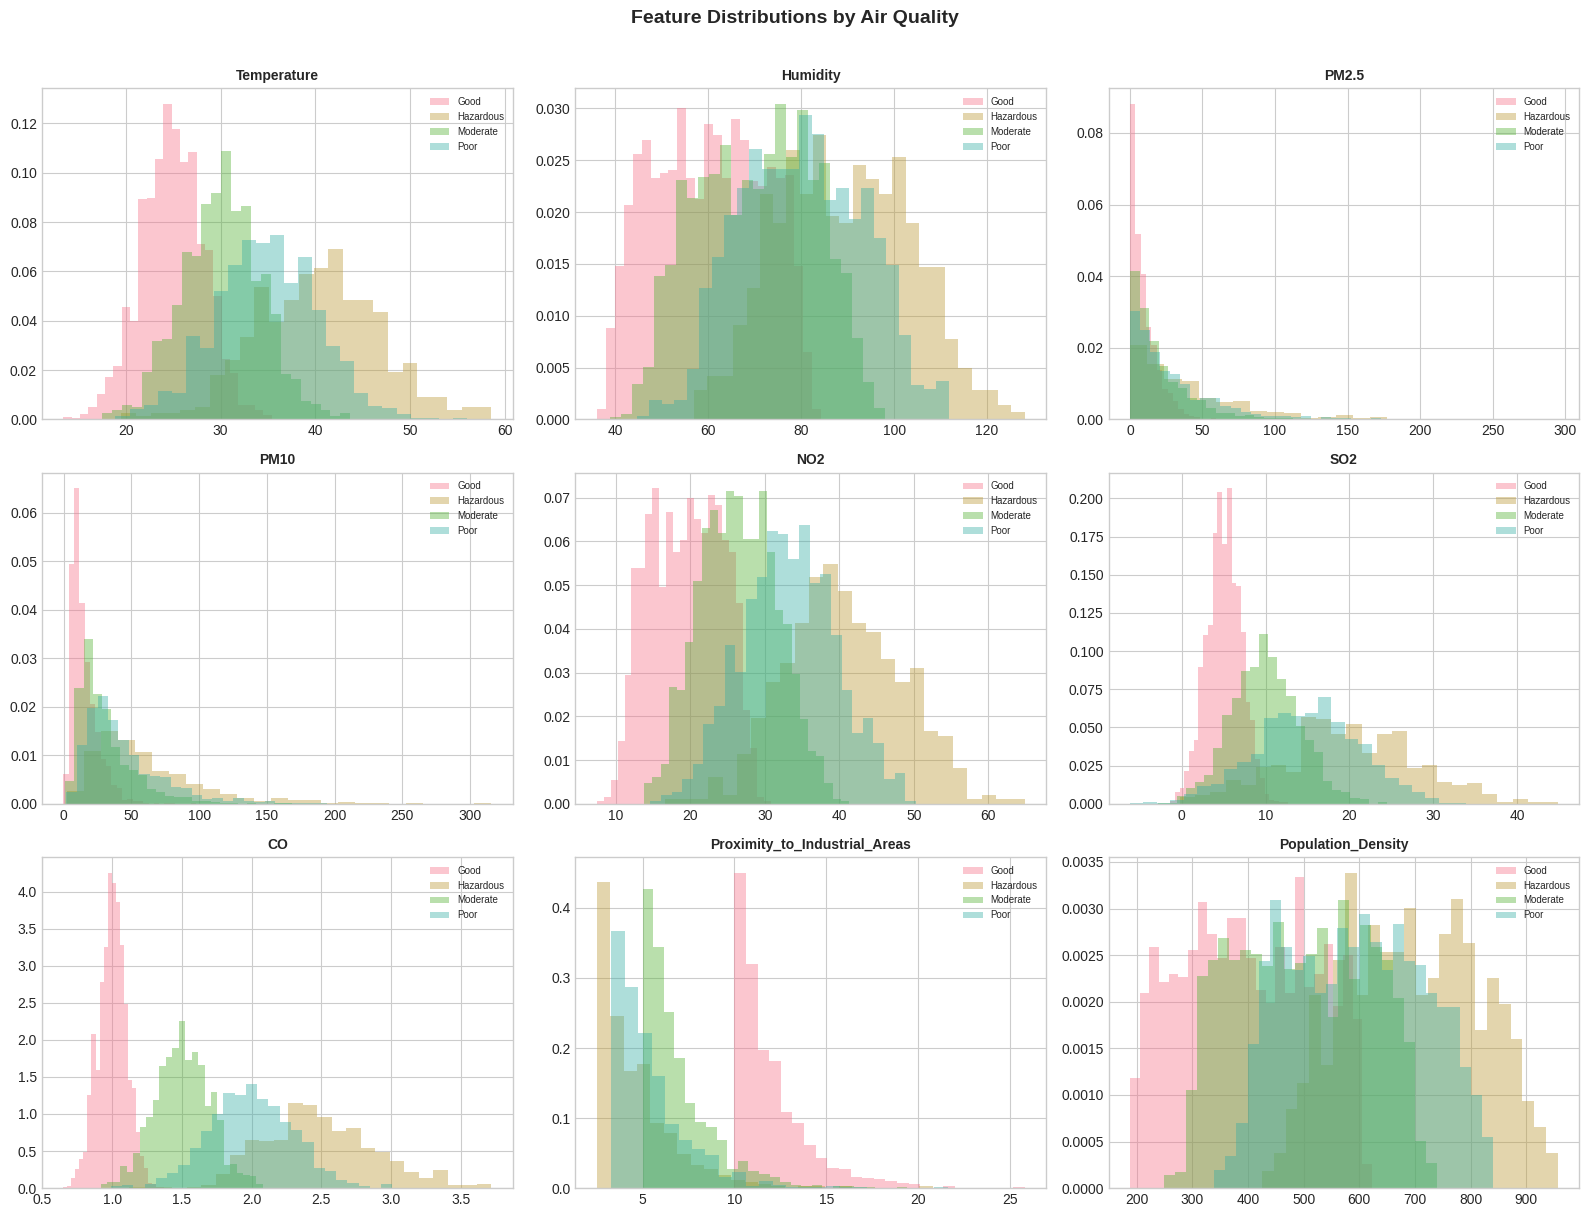

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for cls in sorted(df[target_col].unique()):
            subset = df[df[target_col] == cls][col].dropna()
            lbl = target_labels[cls] if cls < len(target_labels) else f'Class {cls}'
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.4, label=lbl, density=True)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Air Quality', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


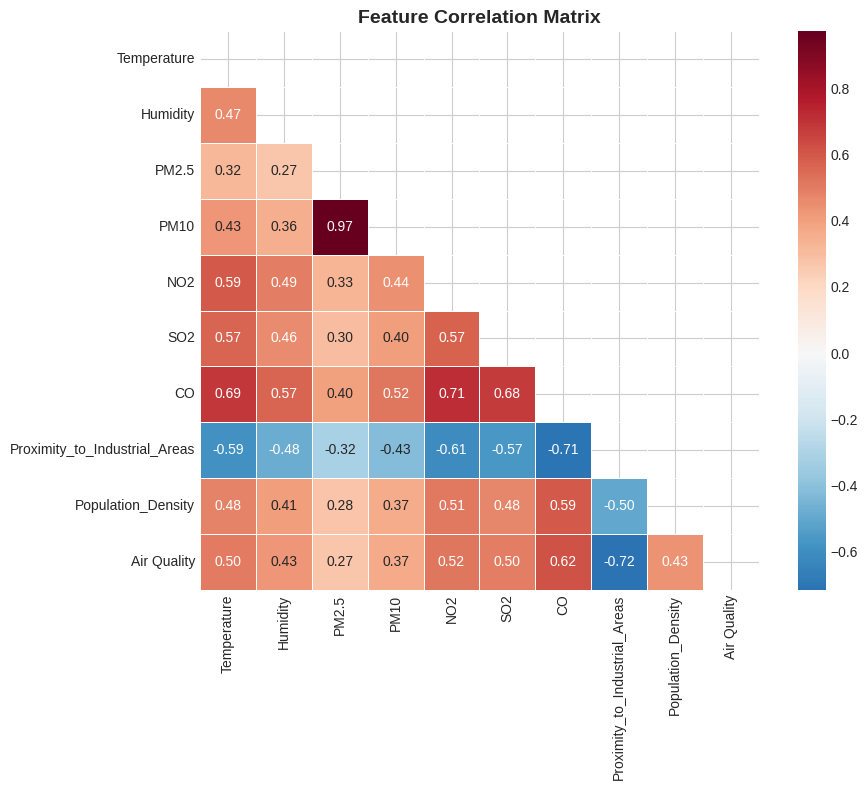

Correlations with air quality (absolute):
  Proximity_to_Industrial_Areas       -0.7157
  CO                                  +0.6189
  NO2                                 +0.5220
  Temperature                         +0.5014
  SO2                                 +0.4973
  Population_Density                  +0.4324
  Humidity                            +0.4306
  PM10                                +0.3665
  PM2.5                               +0.2684


In [7]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with air quality (absolute):")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")


In [8]:
# === Categorical features ===
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'id' not in c.lower()]
if len(cat_cols) > 0:
    plot_cats = cat_cols[:4]
    fig, axes = plt.subplots(1, min(len(plot_cats), 3), figsize=(7 * min(len(plot_cats), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(plot_cats[:3]):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Air Quality', fontsize=11, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print("No categorical features (all numeric dataset).")


No categorical features (all numeric dataset).


## 4. Feature Engineering & Preprocessing

Air quality modelling benefits from domain features:
- **PM2.5/PM10 ratio** — indicates particle source type (combustion vs dust)
- **Pollutant interaction terms** — combined exposure effects
- **WHO/NEPM threshold exceedances** — binary flags for guideline breaches


In [9]:
df_model = df.copy()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    print(f"Dropping: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")
print(f"Target classes: {np.unique(y)}")



Feature matrix: (5000, 9)
Target classes: [0 1 2 3]


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# PM2.5 / PM10 ratio
pm25_cols = [c for c in feature_names if 'pm2' in c.lower() or 'pm25' in c.lower() or 'pm2.5' in c.lower()]
pm10_cols = [c for c in feature_names if 'pm10' in c.lower()]
if pm25_cols and pm10_cols:
    X['pm25_pm10_ratio'] = X[pm25_cols[0]] / (X[pm10_cols[0]] + 1e-6)
    composites_added.append('pm25_pm10_ratio')
    print(f"Created 'pm25_pm10_ratio'")

# Combined pollutant load
pollutant_cols = [c for c in feature_names if any(kw in c.lower() for kw in
                  ['pm2', 'pm10', 'no2', 'so2', 'co', 'o3', 'nox'])]
if len(pollutant_cols) >= 2:
    X['total_pollutant_load'] = X[pollutant_cols].sum(axis=1)
    composites_added.append('total_pollutant_load')
    print(f"Created 'total_pollutant_load' from {pollutant_cols}")

# Temperature-humidity interaction (affects pollutant dispersion)
temp_cols = [c for c in feature_names if 'temp' in c.lower()]
humid_cols = [c for c in feature_names if 'humid' in c.lower() or 'moisture' in c.lower()]
if temp_cols and humid_cols:
    X['temp_humidity_idx'] = X[temp_cols[0]] * X[humid_cols[0]] / 100
    composites_added.append('temp_humidity_idx')
    print(f"Created 'temp_humidity_idx'")

# WHO PM2.5 threshold exceedance (annual mean guideline: 5 ug/m3, 24hr: 15 ug/m3)
if pm25_cols:
    X['pm25_who_exceed'] = (X[pm25_cols[0]] > 15).astype(int)
    composites_added.append('pm25_who_exceed')
    print(f"Created 'pm25_who_exceed' (WHO 24hr guideline: 15 ug/m3)")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'pm25_pm10_ratio'
Created 'total_pollutant_load' from ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']
Created 'temp_humidity_idx'
Created 'pm25_who_exceed' (WHO 24hr guideline: 15 ug/m3)

Total engineered: 4
Final feature count: 13


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
n_classes = len(np.unique(y))
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42,
                                                multi_class='multinomial' if n_classes > 2 else 'auto'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42,
        eval_metric='mlogloss' if n_classes > 2 else 'logloss',
        use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_val, y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'kappa_mean': np.mean(fold_kappa), 'kappa_std': np.std(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9160  F1(w)=0.9151  Kappa=0.8793
  Fold 2: Acc=0.9238  F1(w)=0.9236  Kappa=0.8911
  Fold 3: Acc=0.9250  F1(w)=0.9247  Kappa=0.8926
  -- Mean Acc: 0.9216  F1: 0.9211  Kappa: 0.8877  Time: 6.37s

Training: Random Forest
  Fold 1: Acc=0.9442  F1(w)=0.9438  Kappa=0.9201
  Fold 2: Acc=0.9544  F1(w)=0.9542  Kappa=0.9348
  Fold 3: Acc=0.9562  F1(w)=0.9559  Kappa=0.9373
  -- Mean Acc: 0.9516  F1: 0.9513  Kappa: 0.9307  Time: 1.57s

Training: XGBoost
  Fold 1: Acc=0.9448  F1(w)=0.9447  Kappa=0.9211
  Fold 2: Acc=0.9568  F1(w)=0.9566  Kappa=0.9382
  Fold 3: Acc=0.9568  F1(w)=0.9564  Kappa=0.9381
  -- Mean Acc: 0.9528  F1: 0.9526  Kappa: 0.9325  Time: 1.29s

Training: LightGBM
  Fold 1: Acc=0.9496  F1(w)=0.9492  Kappa=0.9279
  Fold 2: Acc=0.9580  F1(w)=0.9579  Kappa=0.9399
  Fold 3: Acc=0.9598  F1(w)=0.9594  Kappa=0.9424
  -- Mean Acc: 0.9558  F1: 0.9555  Kappa: 0.9367  Time: 1.58s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        "Cohen's Kappa": f"{res['kappa_mean']:.4f} +/- {res['kappa_std']:.4f}",
        'Time': f"{res['time']:.2f}s", 'F1_val': res['f1_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('F1_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', "Cohen's Kappa", 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy     F1 (weighted)     Cohen's Kappa  Time
           LightGBM 0.9558 +/- 0.0044 0.9555 +/- 0.0045 0.9367 +/- 0.0063 1.58s
            XGBoost 0.9528 +/- 0.0056 0.9526 +/- 0.0056 0.9325 +/- 0.0080 1.29s
      Random Forest 0.9516 +/- 0.0053 0.9513 +/- 0.0054 0.9307 +/- 0.0076 1.57s
Logistic Regression 0.9216 +/- 0.0040 0.9211 +/- 0.0043 0.8877 +/- 0.0059 6.37s

Best model: LightGBM


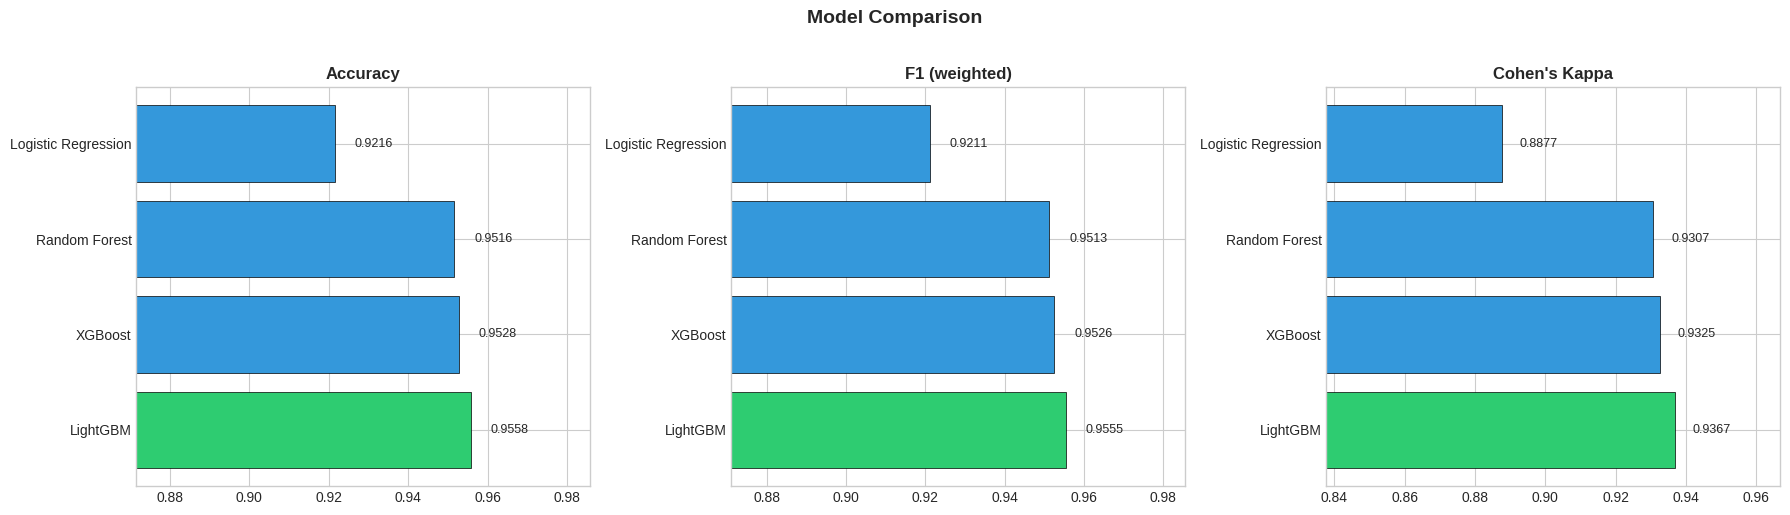

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'kappa_mean'], ['Accuracy', 'F1 (weighted)', "Cohen's Kappa"]):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis

For air quality classification:
- Misclassifying **Hazardous as Good** is a critical public health risk
- Misclassifying **Good as Hazardous** triggers unnecessary advisories (but safer)
- Adjacent category errors (Good→Moderate) are less severe than distant errors (Good→Hazardous)


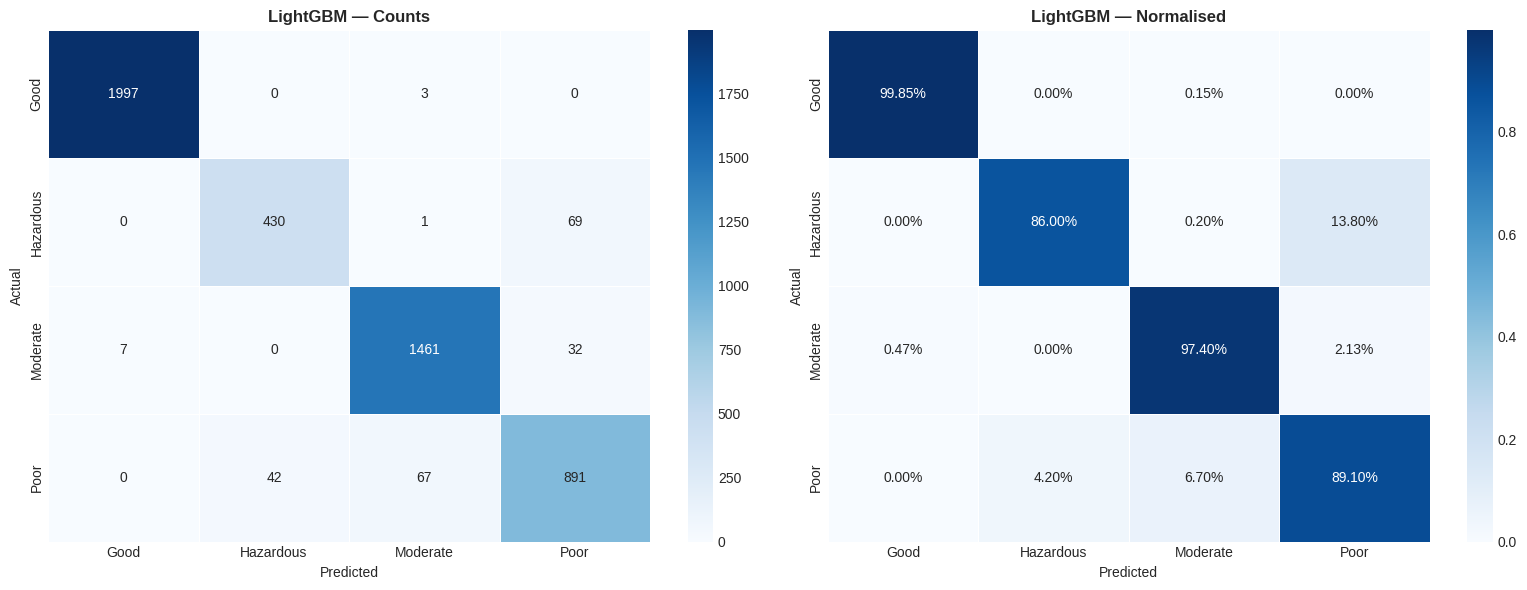


              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      2000
   Hazardous       0.91      0.86      0.88       500
    Moderate       0.95      0.97      0.96      1500
        Poor       0.90      0.89      0.89      1000

    accuracy                           0.96      5000
   macro avg       0.94      0.93      0.94      5000
weighted avg       0.96      0.96      0.96      5000



In [15]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_labels,
            yticklabels=target_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=target_labels,
            yticklabels=target_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")


## 8. Feature Importance & Policy Insights

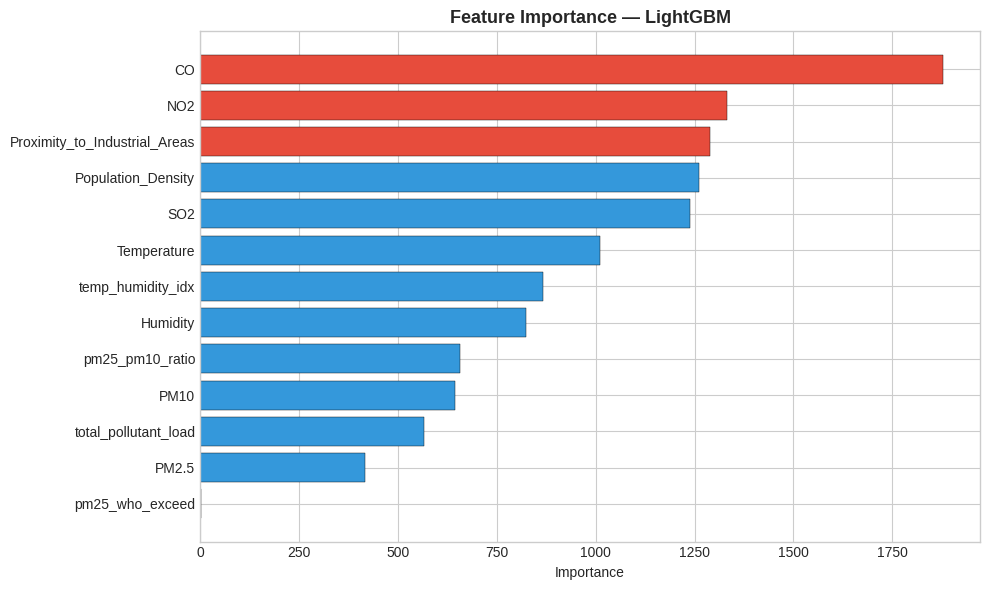

TOP 5 PREDICTIVE FEATURES
  CO                                   1878.0000
  NO2                                  1332.0000
  Proximity_to_Industrial_Areas        1290.0000
  Population_Density                   1262.0000
  SO2                                  1238.0000


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


## 9. Deployment Readiness & Production Considerations

In [17]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Target classes:       {n_classes}")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.70': best_res['accuracy_mean'] > 0.70,
    'F1 (weighted) > 0.65': best_res['f1_mean'] > 0.65,
    'Kappa > 0.50 (moderate+)': best_res['kappa_mean'] > 0.50,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  Accuracy:             0.9558
  F1 (weighted):        0.9555
  Cohen's Kappa:        0.9367
  Training time:        1.6s
  Feature count:        13
  Dataset rows:         5,000
  Target classes:       4
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.70
  [pass] F1 (weighted) > 0.65
  [pass] Kappa > 0.50 (moderate+)
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [18]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: EPA air quality monitoring stations (BAM, TEOM sensors)
   Ingestion: Azure IoT Hub -> Event Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric medallion (bronze=raw, silver=QC'd, gold=features)
   Schedule: Real-time (hourly readings) + daily aggregation

2. MODEL SERVING
   Framework: MLflow on Databricks / Fabric ML
   Endpoint: Real-time (<500ms per station per reading)
   Batch: Daily AQI forecast for next 24-48 hours
   Ensemble: Combine ML prediction with BOM dispersion models

3. INTEGRATION POINTS
   Public dashboard: AQI map (similar to EPA AirWatch / AirRater)
   Health advisory: Automated alerts via emergency broadcast system
   School system: Auto-notification for outdoor activity restrictions
   Transport: Road tunnel ventilation system integration

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> default to sensor-based AQI calculation
   Override: EPA officers can override model classification
   Audit: All predictions logged with sensor readings for validation
   Compliance: NEPM AAQ standards, WHO Air Quality Guidelines 2021

5. MONITORING & RETRAINING
   Drift: PSI on pollutant distributions weekly
   Performance: Accuracy vs official EPA AQI classifications daily
   Retraining: Monthly with validated classifications
   Seasonal: Bushfire season model variant (Oct-Mar)
   Events: Hazard reduction burn and industrial incident modes

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: EPA air quality monitoring stations (BAM, TEOM sensors)
   Ingestion: Azure IoT Hub -> Event Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric medallion (bronze=raw, silver=QC'd, gold=features)
   Schedule: Real-time (hourly readings) + daily aggregation

2. MODEL SERVING
   Framework: MLflow on Databricks / Fabric ML
   Endpoint: Real-time (<500ms per station per reading)
   Batch: Daily AQI forecast for next 24-48 hours
   Ensemble: Combine ML prediction with BOM dispersion models

3. INTEGRATION POINTS
   Public dashboard: AQI map (similar to EPA AirWatch / AirRater)
   Health advisory: Automated alerts via emergency broadcast system
   School system: Auto-notification for outdoor activity restrictions
   Transport: Road tunnel ventilation system integration

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> default to sensor-based AQI calculation
   Override: EPA officers can override model classification